# XGBoost超参数优化：XGBRegressor  最优超参数确定（调参）
## 超参数调优方法：网格搜索，随机搜索，贝叶斯优化等算法
### 2025.02.13 
## 2025.2.21 不同优化的预测效果对比
### sunyu 

XGBRegressor 调整如下参数：
框架参数 XGBRegressor #1: learning_rate
        XGBRegressor #2: n_estimators
        XGBRegressor #3: max_depth
        XGBRegressor #4: subsample
        XGBRegressor #5: alpha
树参数
        XGBRegressor #6: max_depth
        XGBRegressor #7: max_features
        XGBRegressor #8: min_samples_split 
        XGBRegressor #9: min_samples_leaf
        XGBRegressor #10: max_leaf_nodes
        XGBRegressor #11: verbose                            
The type of output to be printed when the model fits. The different values can be:                            
0: no output generated (defaul )
1: output generated for trees in certain inter  ls
>1: output generated for ant XGBRessorate

# API  Default parameters
class sklearn.ensemble.XGBRegressor(
max_depth=3, learning_rate=0.1, n_estimators=100, verbosity=1, silent=None, objective='reg:squarederror', booster='gbtree', n_jobs=1, nthread=None, gamma=0, min_child_weight=1, max_delta_step=0, subsample=1, colsample_bytree=1, colsample_bylevel=1, colsample_bynode=1, reg_alpha=0, reg_lambda=1, scale_pos_weight=1, base_score=0.5, random_state=0, seed=None, missing=None, importance_type='gain')

In [1]:
#导入库
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

from lightgbm.sklearn import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor  #GBDT
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor  #XGBoosting

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Skopt functions   
from skopt import BayesSearchCV
#from skopt.callbacks import DeadlineStopper, DeltaYStopper
#from skopt.space import Real, Categorical, Integer
#No module named 'skopt':  pip install scikit-optimize

from hyperopt import fmin, tpe, hp, anneal, Trials

import seaborn as sns
import matplotlib.pyplot as plt

import math
from scipy.stats import randint
import timeit
import os
import psutil
import missingno as msno

In [1]:
import sklearn
print(sklearn.__version__)

1.5.1


## Hyperopt是一个用于复杂空间下的函数最小化的Python库。它具有强大的灵活性，能处理非常复杂的参数空间。与Skopt不同，Hyperopt使用的是序列模型和贝叶斯优化，并且提供了TPE（树形结构的程序代理）算法来指导搜索。

In [2]:
# 读取CSV文件
data = pd.read_csv('20241128_sunyu.csv',encoding='gbk',header=0)

In [3]:
#data.columns
data

,煤田,矿区,采厚,面长,走向长,推进速度,开采方式,硬岩比,覆岩类型,抗压强度,采深,煤倾,导高
0,4,4,9.10,104.0,0.143045,0.194805,6,0.010,0.4,4.78,610.00,23.0,128.74
1,4,4,12.48,98.1,0.138282,0.194805,6,0.010,0.4,4.78,634.00,21.0,133.30
2,4,4,11.00,100.0,0.133027,0.194805,1,0.010,0.4,4.78,610.00,15.0,126.10
3,35,26,12.00,200.0,0.111348,0.233766,6,0.399,0.4,10.15,552.19,4.0,239.42
4,35,26,6.50,200.0,0.111348,0.233766,6,0.399,0.6,10.15,552.00,4.5,192.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,23,32,1.80,200.0,-0.047627,-0.038961,7,0.260,0.4,15.00,146.00,5.0,15.00
276,22,31,1.20,225.0,0.174084,-0.038961,5,0.660,0.6,35.00,120.00,6.8,31.00
277,34,51,4.00,136.0,0.082115,0.220779,7,0.210,0.4,15.00,350.00,7.0,35.50
278,34,51,3.60,150.0,0.154048,0.285714,7,0.250,0.4,15.00,359.00,7.5,30.20


In [3]:
# 获取特征和目标变量
X = data.drop('导高', axis=1) #'daogao'
y = data['导高']


In [4]:
X

,煤田,矿区,采厚,面长,走向长,推进速度,开采方式,硬岩比,覆岩类型,抗压强度,采深,煤倾
0,4,4,9.10,104.0,0.143045,0.194805,6,0.010,0.4,4.78,610.00,23.0
1,4,4,12.48,98.1,0.138282,0.194805,6,0.010,0.4,4.78,634.00,21.0
2,4,4,11.00,100.0,0.133027,0.194805,1,0.010,0.4,4.78,610.00,15.0
3,35,26,12.00,200.0,0.111348,0.233766,6,0.399,0.4,10.15,552.19,4.0
4,35,26,6.50,200.0,0.111348,0.233766,6,0.399,0.6,10.15,552.00,4.5
...,...,...,...,...,...,...,...,...,...,...,...,...
275,23,32,1.80,200.0,-0.047627,-0.038961,7,0.260,0.4,15.00,146.00,5.0
276,22,31,1.20,225.0,0.174084,-0.038961,5,0.660,0.6,35.00,120.00,6.8
277,34,51,4.00,136.0,0.082115,0.220779,7,0.210,0.4,15.00,350.00,7.0
278,34,51,3.60,150.0,0.154048,0.285714,7,0.250,0.4,15.00,359.00,7.5


In [ ]:
y

In [56]:
# 获取特征和目标变量
#data = data.drop('导高', axis=1) #'daogao'
#targets = data['导高']

In [7]:
# 划分训练集和测试集
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# 划分训练集和测试集
#train_data, test_data, train_targets, test_targets = train_test_split(X, y, test_size=0.20, shuffle=True,random_state=3)

In [4]:
from sklearn.model_selection import KFold, cross_val_score, train_test_split

random_state = 3
n_iter = 50

train_data, test_data, train_targets, test_targets = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=random_state)

num_folds = 5
kf = KFold(n_splits=num_folds) #, random_state=random_state

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True,random_state=3)

In [5]:
#num_folds=2
#random_state=3
#kf = KFold(n_splits=num_folds) #, random_state=3

In [6]:
start=timeit.default_timer()
#内存占用 mb
info_start = psutil.Process(os.getpid()).memory_info().rss/1024/1024
# 划分训练集和测试集
train_data, test_data, train_targets, test_targets = train_test_split(X, y, test_size=0.20, shuffle=True,random_state=3)
num_folds=2
kf = KFold(n_splits=num_folds) #, random_state=3
xgb = XGBRegressor(random_state=3)
score = -cross_val_score(xgb, train_data, train_targets, cv=kf, scoring="neg_mean_squared_error", n_jobs=-1).mean()
print('mse=',score)

end=timeit.default_timer()
info_end = psutil.Process(os.getpid()).memory_info().rss/1024/1024

print('此程序运行占内存'+str(info_end-info_start)+'mB')
print('Running time:%.5fs'%(end-start))

mse= 863.1509491227116
此程序运行占内存0.35546875mB
Running time:2.27269s


In [8]:
xgb

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=3, ...)

# Manual Search手动搜索

In [7]:
# 设置需要调优的超参数
'''   'n_estimators' : range(10, 100, 10), # 估计器数量范围
    'max_depth' : range(1, 10, 1) , #最大深度的选择, 从10到200，步长为1
    'learning_rate':range(1e-3,0.1,10),
    'subsample' : range(0, 1, 10) , # 最小分割样本数量, 从2到100，步长为1
    'min_child_weight' : range(1, 30, 1),  # 从2到100，步长为1
    'cosample_bytree' : range(0, 1, 0.1),  # 从1到100，步长为1
    'max_delta_step' : range(0, 1, 0.1),  # 从2到100，步长为1
    'gamma' : range(0, 100, 10) , # 从0到50，步长为1
    'reg_alpha' : range(1, 10, 1) ,  #
    'reg_lambda': range(0, 50, 10)'''
param_grid = {'learning_rate': np.logspace(-4, 0, 5),
            'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
            'n_estimators': np.linspace(1,150,75, dtype = int),
            'subsample': np.linspace(0.1, 1.0, 10),
            'min_child_weight': [1,3,5],
            'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
            'max_delta_step': np.linspace(0.1, 1.0, 10),
            'max_features': ['sqrt','log2',None] ,#range(1, 10, 1),  # 从1到12，步长为1
            'gamma':np.linspace(0,79,40, dtype = int),
            
            'reg_alpha': np.logspace(-4, 1, 10), # L1 regularization
            'reg_lambda': np.linspace(0,50,51),# L2 regularization
}

<Figure size 400x300 with 0 Axes>

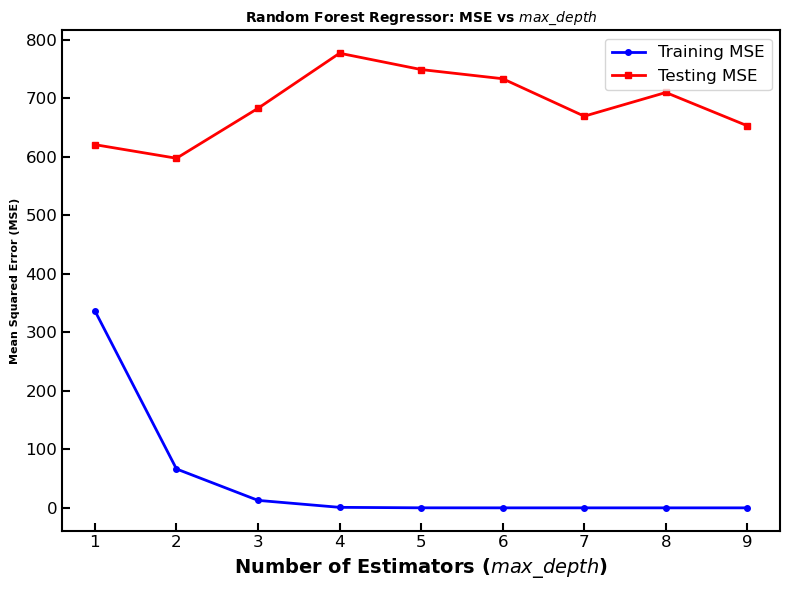

In [9]:
# max_depth 可视化
max_depth_range = range(1, 10, 1)  # 从10到200，步长为10
train_errors = []
test_errors = []
for max_depth in max_depth_range:
    xgb = XGBRegressor(max_depth=max_depth, random_state=42)
    xgb.fit(X_train, y_train)
    
    # 计算训练集和测试集的MSE
    y_train_pred = xgb.predict(X_train)
    y_test_pred = xgb.predict(X_test)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_errors.append(train_mse)
    test_errors.append(test_mse)

# 5. 绘制n_estimators与MSE的关系曲线
plt.figure(figsize=(4, 3))
# 6. 绘制n_estimators与MSE的关系曲线
plt.figure(figsize=(8, 6))
plt.plot(max_depth_range, train_errors, label='Training MSE', color='blue', linewidth=2, marker='o', markersize=4)
plt.plot(max_depth_range, test_errors, label='Testing MSE', color='red', linewidth=2, marker='s', markersize=4)
# 设置字体和字号
plt.xlabel(r'Number of Estimators ($max\_depth$)', fontsize=14, weight='bold')
plt.ylabel(r'Mean Squared Error (MSE)', fontsize=8, weight='bold')
plt.title(r'Random Forest Regressor: MSE vs $max\_depth$', fontsize=10, weight='bold')
# 添加图例
plt.legend(fontsize=12)
# 设置坐标轴刻度
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# 去掉网格线
plt.grid(False)
# 添加四周框线和刻度线
for spine in plt.gca().spines.values():
    spine.set_edgecolor('black')  # 设置框线颜色
    spine.set_linewidth(1.5)      # 设置框线宽度
# 添加刻度线
plt.tick_params(axis='both', which='both', direction='in', length=6, width=1.5)
# 7. 保存为适合出版的图片格式
plt.tight_layout()  # 调整布局，防止内容被裁剪
plt.savefig('XGB_mse_vs_max_depth.svg', dpi=300)  # 保存为300DPI的图片
plt.show()

In [10]:
# 函数用于调优一个超参数
def plot_mse_vs_param(ax, param_name, param_values, model_kwargs, xlabel, filename):
    train_errors = []
    test_errors = []    
    for value in param_values:
        model_kwargs[param_name] = value
        xgb = XGBRegressor(**model_kwargs)
        xgb.fit(X_train, y_train)
        
        # 计算训练集和测试集的MSE
        y_train_pred = xgb.predict(X_train)
        y_test_pred = xgb.predict(X_test)
        
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        
        train_errors.append(train_mse)
        test_errors.append(test_mse)
  
    # 绘制MSE对超参数值的曲线
    ax.plot(param_values, train_errors, label='Training MSE', color='blue', linewidth=2, marker='o', markersize=2)
    ax.plot(param_values, test_errors, label='Testing MSE', color='red', linewidth=2, marker='s', markersize=2)
    
    # 设置标题和标签
    ax.set_xlabel(xlabel, fontsize=8)#, weight='bold')
    ax.set_ylabel(r'MSE (m$^2$)', fontsize=8)#, weight='bold')
    ax.legend(fontsize=8,loc='best')
    ax.tick_params(axis='both', which='both', direction='in', length=4, width=1.5)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
   

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


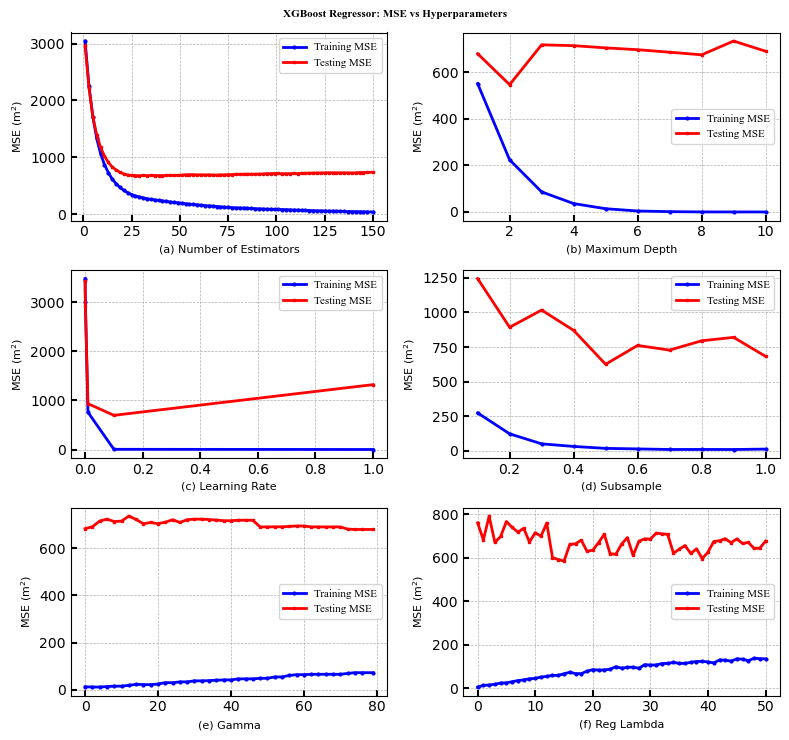

In [11]:
# 4. 创建一个图形窗口，包含多个子图
fig, axes = plt.subplots(3, 2, figsize=(8, 7.5))  # 3行1列的子图   #plt.figure(figsize=(18/2.54, 5/2.54),dpi=400)
plt.rcParams["font.family"] = "Times New Roman"
# 超参数n_estimators
plot_mse_vs_param(axes[0,0],'n_estimators', param_grid['n_estimators'], model_kwargs={'max_depth': 3, 'learning_rate': 0.1},
                  xlabel=r'(a) Number of Estimators', filename='n_estimators_mse_small.png')
#plt.subplot(3, 3, 2)
# 超参数max_depth
plot_mse_vs_param(axes[0,1],'max_depth', param_grid['max_depth'], model_kwargs={'n_estimators': 100, 'learning_rate': 0.1},
                  xlabel=r'(b) Maximum Depth', filename='max_depth_mse_small.png')  # 修改为 max_depth
#plt.subplot(3, 3, 3)# 超参数 max_features
plot_mse_vs_param(axes[1,0],'learning_rate', param_grid['learning_rate'], model_kwargs={'n_estimators': 100},   #'max_depth': None
                  xlabel=r'(c) Learning Rate', filename='learning_rate_mse_small.png')
#plt.subplot(3, 3, 4) # min_samples_split
plot_mse_vs_param(axes[1,1],'subsample', param_grid['subsample'], model_kwargs={'n_estimators': 100, 'max_depth': 3},
                  xlabel=r'(d) Subsample', filename='subsample_mse_small.png')     

#plt.subplot(3, 3, 5) # max_leaf_nodes
plot_mse_vs_param(axes[2,0],'gamma', param_grid['gamma'], model_kwargs={'n_estimators': 100, 'max_depth': 3},
                  xlabel=r'(e) Gamma', filename='gamma_mse_small.png')
#plt.subplot(3, 3, 6) # min_samples_leaf
#plot_mse_vs_param(axes[1,2],'min_child_weight', param_grid['min_child_weight'], model_kwargs={'min_child_weight': 100, 'max_depth': None},
#                  xlabel=r'Min Child Weight ($min\_child\_weight$)', filename='min_child_weight_mse_small.png')
#plt.subplot(3, 3, 7) # max_samples
#plot_mse_vs_param(axes[2,0],'colsample_bytree', param_grid['colsample_bytree'], model_kwargs={'n_estimators': 100, 'max_depth': 3},
#                  xlabel=r'colsample bytree ($colsample\_bytree$)', filename='colsample_bytree_mse_small.png')
#plt.subplot(3, 3, 8) # random_state
#plot_mse_vs_param(axes[2,1],'max_delta_step', param_grid['max_delta_step'], model_kwargs={'n_estimators': 100, 'max_depth': 3},
#                  xlabel=r'Max Delta Step ($max\_delta\_step$)', filename='max_delta_step_mse_small.png')
#plot_mse_vs_param(axes[2,0],'reg_alpha', param_grid['reg_alpha'], model_kwargs={'n_estimators': 100, 'max_depth': 3},
                  #xlabel=r'reg alpha ($reg\_alpha$)', filename='reg_alpha_mse_small.png')
plot_mse_vs_param(axes[2,1],'reg_lambda', param_grid['reg_lambda'], model_kwargs={'n_estimators': 100, 'max_depth': 3},
                  xlabel=r'(f) Reg Lambda', filename='reg_lambda_mse_small.png')

# 设置图表的总体标题
fig.suptitle('XGBoost Regressor: MSE vs Hyperparameters', fontsize=8, weight='bold')

# 调整布局，防止标签被遮挡
plt.tight_layout()
plt.subplots_adjust(top=0.95)  # 调整整体标题的位置

# 保存为适合出版的图片格式
plt.savefig('XGBoost_all_params_mse0420.tiff',bbox_inches='tight', dpi=300)
plt.savefig('XGBoost_all_params_mse0420.svg',bbox_inches='tight', dpi=300)
plt.savefig('XGBoost_all_params_mse0420.eps',bbox_inches='tight', dpi=300)
plt.savefig('XGBoost_all_params_mse0420.pdf',bbox_inches='tight', dpi=300)
plt.show()

# XGBoost Regressor and GridSearch

In [11]:
'''
param_grid={'learning_rate': np.logspace(-4, 0, 5),
            'max_depth':  np.linspace(1,20,20,dtype = int),#最大深度的选择, 从1到20，步长为1
            'n_estimators': np.linspace(1,150,150, dtype = int),
            'subsample': np.linspace(0.1, 1.0, 10),
            #'min_child_weight': [1,3,5],
            #'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
            #'max_delta_step': np.linspace(0.1, 1.0, 10),
            'max_features': ['sqrt','log2',None] ,#range(1, 10, 1),  # 从1到12，步长为1
            'gamma':np.linspace(0,100,101, dtype = int),
            
            'reg_alpha': np.logspace(-4, 1, 10), # L1 regularization
            'reg_lambda': np.linspace(0,50,51),# L2 regularization
           }
'''

In [5]:
#param_grid={#'learning_rate': np.logspace(-4, 0, 5),
           # 'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
           # 'n_estimators': np.linspace(1,150,150, dtype = int),
            #'subsample': np.linspace(0.1, 1.0, 10),
            #'min_child_weight': [1,3,5],
            #'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
            #'max_delta_step': np.linspace(0.1, 1.0, 10),
            #'max_features': ['sqrt','log2',None] ,#range(1, 10, 1),  # 从1到12，步长为1
            #'gamma':np.linspace(0,100,101, dtype = int),
            
            #'reg_alpha': np.logspace(-4, 1, 10), # L1 regularization
            #'reg_lambda': np.linspace(0,50,51),# L2 regularization
#           }

In [ ]:
#'learning_rate': np.logspace(-4, 0, 5),
#'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
#'n_estimators': np.linspace(30,150,120, dtype = int),
#此程序运行占内存10.5234375mB
#Running time:141.36394s
#Best MSE 734.860 params {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 138}
#时间占用 s
start=timeit.default_timer()
#内存占用 mb
info_start = psutil.Process(os.getpid()).memory_info().rss/1024/1024
# MemoryError 当参数过多，就出现内存错误
param_grid={'learning_rate': np.logspace(-4, 0, 5),
            'max_depth':  np.linspace(3,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
            'n_estimators': np.linspace(30,150,120, dtype = int),
            #'subsample': np.linspace(0.1, 1.0, 10),  #Best MSE 780.007 params {'learning_rate': 0.1, 'n_estimators': 109, 'subsample': 0.4}
            #'min_child_weight': [1,3,5],
            #'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
            #'max_delta_step': np.linspace(0.1, 1.0, 10),
            #'gamma':np.linspace(0,100,101, dtype = int),
            #'reg_alpha': np.logspace(-4, 1, 5), # L1 regularization
            #'reg_lambda': np.linspace(0,50,51)# L2 regularization    MSE 875.392
           }
xgb = XGBRegressor(random_state=3)
gs=GridSearchCV(xgb, param_grid, scoring='neg_mean_squared_error', #fit_params=None, 
                n_jobs=-1, cv=kf, verbose=1)
gs.fit(train_data, train_targets)
gs_test_score=mean_squared_error(test_targets, gs.predict(test_data))

end=timeit.default_timer()
info_end = psutil.Process(os.getpid()).memory_info().rss/1024/1024

print('此程序运行占内存'+str(info_end-info_start)+'mB')
print('Running time:%.5fs'%(end-start))
print("Best MSE {:.3f} params {}".format(-gs.best_score_, gs.best_params_))

Fitting 2 folds for each of 6000 candidates, totalling 12000 fits


In [ ]:
# -------------------
# Predicting ...
# -------------------
y_pred = gs.predict(test_data)
np.set_printoptions(precision=2)
test_results_gs_df=pd.DataFrame({
    'Actual': test_targets,
    'Predicted_gs': y_pred
})
test_results_gs_df.to_csv('test_predictions_gs.csv',index=False)
#np.concatenate(test_targets.reshape(len(y_test), 1)),(y_pred.reshape(len(y_pred), 1), axis=1) 


In [99]:
'''
#时间占用 s
start=timeit.default_timer()
#内存占用 mb
info_start = psutil.Process(os.getpid()).memory_info().rss/1024/1024

param_grid={'learning_rate': np.logspace(-3, -1, 10),
            'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
            'n_estimators': np.linspace(30,150,120, dtype = int),
            'booster':['gbtree','dart','gblinear'],
#            'subsample': np.linspace(0.1, 1.0, 10),
#            'min_child_weight': [1,3,5],
#            'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
#            'max_delta_step': np.linspace(0.1, 1.0, 10),
#            'max_features': ['sqrt','log2',None] ,#range(1, 10, 1),  # 从1到12，步长为1
#            'gamma':np.linspace(0,100,101, dtype = int),
            
#            'reg_alpha': np.logspace(-4, 1, 10), # L1 regularization
#            'reg_lambda': np.linspace(0,50,51),# L2 regularization
           }
xgb = XGBRegressor(random_state=3)
gs=GridSearchCV(xgb, param_grid, scoring='neg_mean_squared_error', #fit_params=None, 
                n_jobs=-1, cv=kf, verbose=False)
gs.fit(train_data, train_targets)
gs_test_score=mean_squared_error(test_targets, gs.predict(test_data))

end=timeit.default_timer()
info_end = psutil.Process(os.getpid()).memory_info().rss/1024/1024

print('此程序运行占内存'+str(info_end-info_start)+'mB')
print('Running time:%.5fs'%(end-start))
print("Best MSE {:.3f} params {}".format(-gs.best_score_, gs.best_params_))
'''

此程序运行占内存-34.0625mB
Running time:1420.81161s
Best MSE 734.860 params {'booster': 'gbtree', 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 138}


In [18]:
'''
# iteration 2 find other parameters 
param_grid={#'learning_rate': np.logspace(-3, -1, 10),
            #'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
            #'n_estimators': np.linspace(30,150,120, dtype = int),
            'subsample': np.linspace(0.1, 1.0, 10),
            'min_child_weight': [1,3,5],
            'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
            'max_delta_step': np.linspace(0.1, 1.0, 10),
            'booster':['gbtree','dart','gblinear'],
#            'max_features': ['sqrt','log2',None] ,#range(1, 10, 1),  # 从1到12，步长为1
#            'gamma':np.linspace(0,100,101, dtype = int),
            
#            'reg_alpha': np.logspace(-4, 1, 10), # L1 regularization
#            'reg_lambda': np.linspace(0,50,51),# L2 regularization
           }
xgb = XGBRegressor(learning_rate=0.1,max_depth=2,n_estimators=138,random_state=3)
gs=GridSearchCV(xgb, param_grid, scoring='neg_mean_squared_error', #fit_params=None, 
                n_jobs=-1, cv=kf, verbose=False)
gs.fit(train_data, train_targets)
gs_test_score=mean_squared_error(test_targets, gs.predict(test_data))

print("Best MSE {:.3f} params {}".format(-gs.best_score_, gs.best_params_))
'''

Best MSE 2697.912 params {'colsample_bytree': 0.8, 'max_delta_step': 1.0, 'min_child_weight': 5, 'subsample': 0.8}


In [62]:
'''
# iteration 3 find other parameters 
param_grid={'learning_rate': np.logspace(-3, -1, 10),
            'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
            'n_estimators': np.linspace(30,150,120, dtype = int),
#            'subsample': np.linspace(0.1, 1.0, 10),
#            'min_child_weight': [1,3,5],
#            'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
#            'max_delta_step': np.linspace(0.1, 1.0, 10),
            #'gamma':np.linspace(0,100,101, dtype = int),       
            #'reg_alpha': np.logspace(-4, 1, 10), # L1 regularization
            #'reg_lambda': np.linspace(0,50,51),# L2 regularization
           }
xgb = XGBRegressor(#learning_rate=0.1,max_depth=2,n_estimators=138,subsample=0.8,min_child_weight=5,max_delta_step=1.0,colsample_bytree=0.8,random_state=3
)
gs=GridSearchCV(xgb, param_grid, scoring='neg_mean_squared_error', #fit_params=None, 
                n_jobs=-1, cv=kf, verbose=False)
gs.fit(train_data, train_targets)
gs_test_score=mean_squared_error(test_targets, gs.predict(test_data))

print("Best MSE {:.3f} params {}".format(-gs.best_score_, gs.best_params_))
'''

Best MSE 734.860 params {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 138}


In [11]:
xgb

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None, max_delta=1.0,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=138, n_jobs=None,
             num_parallel_tree=None, ...)

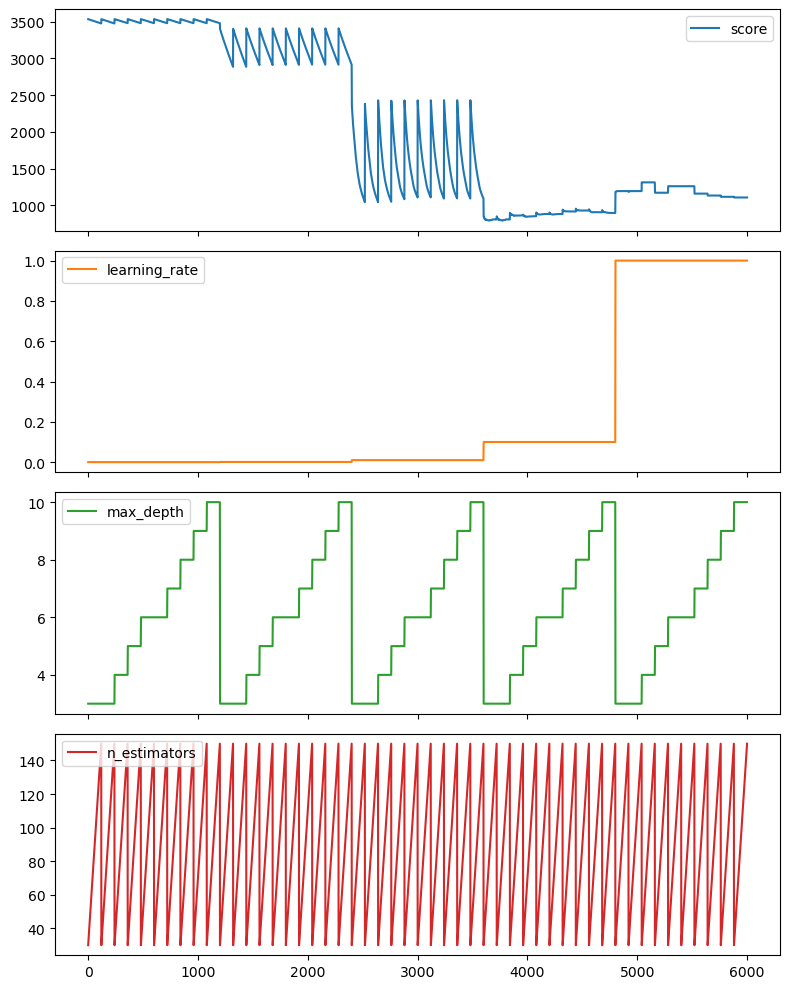

In [10]:
import matplotlib.pyplot as plt
gs_results_df=pd.DataFrame(np.transpose([-gs.cv_results_['mean_test_score'],
                                         gs.cv_results_['param_learning_rate'].data,
                                         gs.cv_results_['param_max_depth'].data,
                                         gs.cv_results_['param_n_estimators'].data]),
                           columns=['score', 'learning_rate', 'max_depth', 'n_estimators'])
gs_results_df
gs_results_df.plot(subplots=True,figsize=(8, 10))
plt.tight_layout()  # 调整布局，防止内容被裁剪
plt.savefig('xgboost_tuningParas214.png', dpi=300)  # 保存为300DPI的图片
plt.show()

In [11]:
gs_results_df

,score,learning_rate,max_depth,n_estimators
0,3532.694513,0.0001,3.0,30.0
1,3532.201380,0.0001,3.0,31.0
2,3531.708294,0.0001,3.0,32.0
3,3531.215402,0.0001,3.0,33.0
4,3530.722557,0.0001,3.0,34.0
...,...,...,...,...
5995,1107.319608,1.0000,10.0,145.0
5996,1107.319608,1.0000,10.0,146.0
5997,1107.319608,1.0000,10.0,147.0
5998,1107.319608,1.0000,10.0,148.0


In [12]:
gs_results_df.to_csv('gs_results.csv',index=False)

Text(0, 0.5, 'best_cumulative_score')

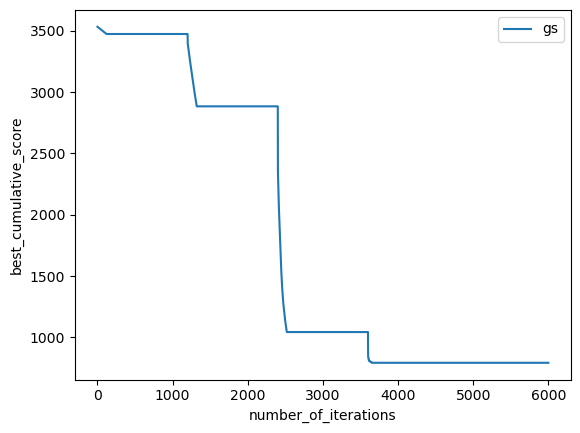

In [18]:
scores_df_gs = pd.DataFrame(index=range(n_iter*120))#
scores_df_gs["gs"] = gs_results_df["score"].cummin()
ax = scores_df_gs.plot()

ax.set_xlabel("number_of_iterations")
ax.set_ylabel("best_cumulative_score")

In [ ]:
gs_results_df.to_csv('gs_results.csv',index=False)

In [58]:
gs_results_df["score"]

0       3537.999927
1       3537.683175
2       3537.366454
3       3537.049876
4       3536.733328
           ...     
5995    1107.319608
5996    1107.319608
5997    1107.319608
5998    1107.319608
5999    1107.319608
Name: score, Length: 6000, dtype: float64

In [24]:
'''
# 设置需要调优的超参数
param_grid = {
    
#    'learning_rate': np.linspace(0.001,0.1,10), #== 'eta':np.linspace(0.001,0.1,10),
#    'n_estimators' : range(10, 100, 5), # 估计器数量范围
#    'subsample': np.linspace(0.1, 1.0, 10),
#    'min_child_weight': [1,2,3,4,5,6],
#    'colsample_bytree':[0.5,0.7],
#    'gamma': np.linspace(0,100),
#    'alpha': np.linspace(0.1,0.9,9),
#    'max_depth' : range(1, 10, 1) , #最大深度的选择, 从10到200，步长为1
#    'max_features' : ['sqrt','log2',None] #range(1, 10, 1),  # 从1到12，步长为1
#    'min_samples_split' : range(2, 10, 1) , # 最小分割样本数量, 从2到100，步长为1
#    'min_samples_leaf' : range(1, 50, 1),  # 从1到100，步长为1
#    'max_leaf_nodes' : range(2, 30, 1),  # 从2到100，步长为1
#    'min_impurity_decrease': np.linspace(0.1,0.9,9),
#    'random_state' : range(0, 50, 1) , # 从0到50，步长为1
#    'objective':['reg:squarederror']
    'scale_pos_weight':np.linspace(0.1,1.0,10),
}
'''

In [8]:
'''
xgb = XGBRegressor(learning_rate=0.067,n_estimators = 95,subsample=0.3,max_depth=9,random_state=3)  #max_features=5,learning_rate=0.02,
grid_search = GridSearchCV(estimator = xgb, param_grid = param_grid,  scoring='neg_mean_squared_error',  n_jobs = -1,verbose = 1)#cv = 5, verbose =2,'r2'
grid_search.fit(X_train, y_train)
'''

"\nxgb = XGBRegressor(learning_rate=0.067,n_estimators = 95,subsample=0.3,max_depth=9,random_state=3)  #max_features=5,learning_rate=0.02,\ngrid_search = GridSearchCV(estimator = xgb, param_grid = param_grid,  scoring='neg_mean_squared_error',  n_jobs = -1,verbose = 1)#cv = 5, verbose =2,'r2'\ngrid_search.fit(X_train, y_train)\n"

In [22]:
'''
#best params 2025.02.14 Best MSE 2650.049 
xgb = XGBRegressor(learning_rate=0.1,n_estimators = 138,subsample=0.8,max_depth=2,colsample_bytree=0.8, max_delta_step=1.0, min_child_weight=5, gamma=0, max_features='sqrt', reg_alpha=10.0, reg_lambda=8.0,random_state=3)  #max_features=5,learning_rate=0.02,
#grid_search = GridSearchCV(estimator = xgb, param_grid = param_grid,  scoring='neg_mean_squared_error',  n_jobs = -1,verbose = 1)#cv = 5, verbose =2,'r2'
#grid_search.fit(X_train, y_train)
xgb.fit(train_data,train_targets)
gs_test_score=mean_squared_error(test_targets, xgb.predict(test_data))
print("Best MSE {:.3f} ".format(gs_test_score))
'''

Best MSE 2650.049 


E:\anaconda\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:32:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "max_features" } are not used.

  warnings.warn(smsg, UserWarning)


In [1]:
# grid_search.best_params_

In [ ]:
# Best params

# RandomsizeSearch

In [47]:
from scipy.stats import randint
param_grid_rand={
    'learning_rate': np.logspace(-4, 0, 100),
    'max_depth':  randint(2,20),
    'n_estimators': randint(10,150),
    'random_state': [3,5,7,9]
}

xgb=XGBRegressor()
rs = RandomizedSearchCV(
    xgb,
    param_grid_rand,
    n_iter=n_iter,
    scoring="neg_mean_squared_error",
    #fit_params=None,
    n_jobs=-1,
    cv=kf,  # kf,
    verbose=1,
    random_state=random_state,
)

rs.fit(train_data, train_targets)

rs_test_score = mean_squared_error(test_targets, rs.predict(test_data))

print("Best MSE {:.3f} params {}".format(-rs.best_score_, rs.best_params_))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best MSE 895.271 params {'learning_rate': 0.394420605943766, 'max_depth': 4, 'n_estimators': 21, 'random_state': 5}


In [23]:
# -------------------
# Predicting ...
# -------------------
y_pred = rs.predict(test_data)
np.set_printoptions(precision=2)
test_results_rs_df=pd.DataFrame({
    'Actual': test_targets,
    'Predicted_rs': y_pred
})
test_results_rs_df.to_csv('test_predictions_rs.csv',index=False)
#np.concatenate(test_targets.reshape(len(y_test), 1)),(y_pred.reshape(len(y_pred), 1), axis=1) 


In [48]:
#Best MSE 745.990 params {'learning_rate': 0.08902150854450393, 'max_depth': 2, 'n_estimators': 122, 'random_state': 3}
#Best MSE 760.308 params {'learning_rate': 0.10974987654930568, 'max_depth': 2, 'n_estimators': 145, 'random_state': 3}
#时间占用 s
start=timeit.default_timer()
#内存占用 mb
info_start = psutil.Process(os.getpid()).memory_info().rss/1024/1024
rs=RandomizedSearchCV(xgb, param_grid_rand, n_iter = 50, scoring='neg_mean_squared_error', #fit_params=None, 
                n_jobs=-1, cv=5,  random_state=5) #best_cumulative_score

rs.fit(train_data, train_targets)

rs_test_score=mean_squared_error(test_targets, rs.predict(test_data))
end=timeit.default_timer()
info_end = psutil.Process(os.getpid()).memory_info().rss/1024/1024

print('此程序运行占内存'+str(info_end-info_start)+'mB')
print('Running time:%.5fs'%(end-start))
print("Best MSE {:.3f} params {}".format(-rs.best_score_, rs.best_params_))


此程序运行占内存0.0390625mB
Running time:6.07849s
Best MSE 853.967 params {'learning_rate': 0.1291549665014884, 'max_depth': 3, 'n_estimators': 124, 'random_state': 9}


In [28]:
'''
# iteration 2 find other parameters 
param_grid_rand={#'learning_rate': np.logspace(-3, -1, 10),
            #'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
            #'n_estimators': np.linspace(30,150,120, dtype = int),
            'subsample': np.linspace(0.1, 1.0, 10),
            'min_child_weight': [1,3,5],
            'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
            'max_delta_step': np.linspace(0.1, 1.0, 10),
#            'max_features': ['sqrt','log2',None] ,#range(1, 10, 1),  # 从1到12，步长为1
#            'gamma':np.linspace(0,100,101, dtype = int),
            
#            'reg_alpha': np.logspace(-4, 1, 10), # L1 regularization
#            'reg_lambda': np.linspace(0,50,51),# L2 regularization
           }
xgb = XGBRegressor(learning_rate=1.0,max_depth=5,n_estimators=145,random_state=3)
rs=RandomizedSearchCV(xgb, param_grid_rand, n_iter = 50, scoring='neg_mean_squared_error', #fit_params=None, 
                n_jobs=-1, cv=kf, verbose=False, random_state=random_state)
rs.fit(train_data, train_targets)
rs_test_score=mean_squared_error(test_targets, rs.predict(test_data))

print("Best MSE {:.3f} params {}".format(-rs.best_score_, rs.best_params_))
'''

Best MSE 916.443 params {'subsample': 0.4, 'min_child_weight': 5, 'max_delta_step': 0.9, 'colsample_bytree': 0.9}


In [50]:

# iteration 3 find other parameters 
param_grid_rand={'learning_rate': np.logspace(-3, -1, 10),
            #'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
            #'n_estimators': np.linspace(30,150,120, dtype = int),
#            'subsample': np.linspace(0.1, 1.0, 10),
#            'min_child_weight': [1,3,5],
#            'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
#            'max_delta_step': np.linspace(0.1, 1.0, 10),
#            'max_features': ['sqrt','log2',None] ,#range(1, 10, 1),  # 从1到12，步长为1
            'gamma':np.linspace(0,100,101, dtype = int),
            
            'reg_alpha': np.logspace(-4, 1, 10), # L1 regularization
            'reg_lambda': np.linspace(0,50,51),# L2 regularization
           }
xgb = XGBRegressor(learning_rate=1.0,max_depth=5,n_estimators=145,subsample=0.4,min_child_weight=5,max_delta=0.9,colsample_bytree=0.9,random_state=3)
rs=RandomizedSearchCV(xgb, param_grid_rand, scoring='neg_mean_squared_error', #fit_params=None, 
                n_jobs=-1, cv=kf, verbose=False)
rs.fit(train_data, train_targets)
rs_test_score=mean_squared_error(test_targets, rs.predict(test_data))

print("Best MSE {:.3f} params {}".format(-rs.best_score_, rs.best_params_))


Best MSE 825.975 params {'reg_lambda': 21.0, 'reg_alpha': 0.004641588833612782, 'learning_rate': 0.1, 'gamma': 52}


E:\anaconda\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:16:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "max_delta" } are not used.

  warnings.warn(smsg, UserWarning)


In [52]:
import matplotlib.pyplot as plt
rs_results_df=pd.DataFrame(np.transpose([-rs.cv_results_['mean_test_score'],
                                         rs.cv_results_['param_learning_rate'].data,
                                         rs.cv_results_['param_max_depth'].data,
                                         rs.cv_results_['param_n_estimators'].data]),
                           columns=['score', 'learning_rate', 'max_depth', 'n_estimators'])
rs_results_df.plot(subplots=True, figsize=(10, 10))

KeyError: 'param_max_depth'

In [25]:
rs_results_df.to_csv('rs_results.csv',index=False)

Text(0, 0.5, 'best_cumulative_score')

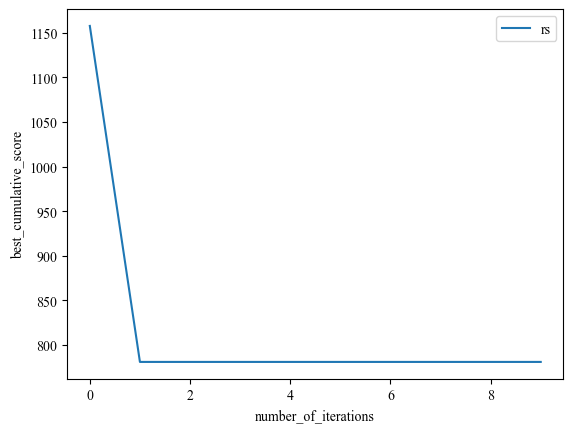

In [51]:
scores_df = pd.DataFrame(index=range(n_iter))
scores_df["rs"] = rs_results_df["score"].cummin()
ax = scores_df.plot()

ax.set_xlabel("number_of_iterations")
ax.set_ylabel("best_cumulative_score")

In [12]:
'''
import matplotlib.pyplot as plt
rs_results_df=pd.DataFrame(np.transpose([-rs.cv_results_['mean_test_score'],
                                         rs.cv_results_['param_learning_rate'].data,
                                         rs.cv_results_['param_max_depth'].data,
                                         rs.cv_results_['param_n_estimators'].data,
                                         rs.cv_results_['param_subsample'].data,
                                         rs.cv_results_['param_min_child_weight'].data,
                                         rs.cv_results_['param_colsample_ratio'].data,
                                         rs.cv_results_['param_max_delta_step'].data,
                                         rs.cv_results_['param_gamma'].data,
                                         rs.cv_results_['param_reg_alpha'].data,
                                         rs.cv_results_['param_reg_lambda'].data]),
                           columns=['score', 'learning_rate', 'max_depth', 'n_estimators',
                                    'subsample','min_child_weight','colsample_ratio','max_delta_step','gamma','reg_alpha','reg_lambda'])
rs_results_df.plot(subplots=True,figsize=(21, 10))
plt.tight_layout()  # 调整布局，防止内容被裁剪
plt.savefig('xgboost_tuningParas_RS_214.png', dpi=300)  # 保存为300DPI的图片
plt.show()
'''

"\nimport matplotlib.pyplot as plt\nrs_results_df=pd.DataFrame(np.transpose([-rs.cv_results_['mean_test_score'],\n                                         rs.cv_results_['param_learning_rate'].data,\n                                         rs.cv_results_['param_max_depth'].data,\n                                         rs.cv_results_['param_n_estimators'].data,\n                                         rs.cv_results_['param_subsample'].data,\n                                         rs.cv_results_['param_min_child_weight'].data,\n                                         rs.cv_results_['param_colsample_ratio'].data,\n                                         rs.cv_results_['param_max_delta_step'].data,\n                                         rs.cv_results_['param_gamma'].data,\n                                         rs.cv_results_['param_reg_alpha'].data,\n                                         rs.cv_results_['param_reg_lambda'].data]),\n                           columns=['score

# Bayesian Optimization with XGBoost

## TPE

In [53]:
from hyperopt import fmin, tpe, hp, anneal, Trials

可用的 hyperopt 优化算法包括 -
hp.choice(label, options) — 返回其中一个选项，该选项应为列表或元组。
hp.randint(label, upper) — 返回范围 [0, upper) 之间的随机整数。
hp.uniform(label, low, high) — 返回介于 low 和 high 之间的均匀值。
hp.quniform(label, low, high, q) — 返回值 round(uniform(low, high) / q) * q，即对小数值进行四舍五入并返回一个整数。
hp.normal(label, mean, std) — 返回具有平均值和标准差 sigma 的正态分布的实值。

In [54]:
def gb_mse_cv(params, random_state=random_state, cv=kf, X=train_data, y=train_targets):
    # the function gets a set of variable parameters in "param"
    params = {'n_estimators': int(params['n_estimators']), 
              'max_depth': int(params['max_depth']), 
              'learning_rate': params['learning_rate'],
              #'subsample': params['subsample'],
              #'min_child_weight': params['min_child_weight'],
              #'colsample_bytree':params['colsample_bytree'], # subsample ratio of columns by tree
              #'max_delta_step': params['max_delta_step'],
             #'max_features': params['max_features'] ,#range(1, 10, 1),  # 从1到12，步长为1
             #'gamma':params['gamma'],            
             #'reg_alpha': params['reg_alpha'], # L1 regularization
             #'reg_lambda': params['reg_lambda'],# L2 regularization
             # 'booster':params['booster']
             }
    
    # we use this params to create a new LGBM Regressor
    xgb = XGBRegressor(random_state=random_state, **params)
    
    # and then conduct the cross validation with the same folds as before
    score = -cross_val_score(xgb, X, y, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1).mean()
    print(score,params)

    return score

In [55]:
#Best MSE 752.202 params {'learning_rate': 0.08316060553979136, 'max_depth': 2.0, 'n_estimators': 96.0}
#Best MSE 3547.530 params {'colsample_bytree': 0.0, 'max_delta_step': 0.0, 'min_child_weight': 4.0, 'subsample': 0.0}
#Best MSE 816.804 params {'gamma': 4.772389046420221, 'reg_alpha': 72.0, 'reg_lambda': 0.10478729061580111}
# Best MSE 3547.530 params {'colsample_bytree': 0.0, 'gamma': 8.946919502838902, 'learning_rate': 0.06992132555536061, 'max_delta_step': 0.0, 
# 'max_depth': 9.0, 'min_child_weight': 0.0, 'n_estimators': 100.0, 'reg_alpha': 50.0, 'reg_lambda': 0.6536912918472014, 'subsample': 0.0}
# 状态空间，最小化函数的params的取值范围
space={'n_estimators': hp.quniform('n_estimators', 30, 150, 1),
       #'booster':hp.choice('booster',['gbtree','dart','gblinear']),
       'max_depth' : hp.quniform('max_depth', 2, 10, 1),
       'learning_rate': hp.loguniform('learning_rate', -5, 0),
       #'subsample': hp.quniform('subsample', 0.1, 1.0, 10),
       #'min_child_weight': hp.quniform('min_child_weight',1,7,4),
       #'colsample_bytree': hp.quniform('colsample_bytree',0.1, 1.0, 10), # subsample ratio of columns by tree
      # 'max_delta_step': hp.quniform('max_delta_step',0.1, 1.0, 10),
       #'max_features':hp.choice('max_features',['auto','sqrt','log2',None]), 
#       'gamma':hp.uniform('gamma',1,9),            
#       'reg_alpha': hp.quniform('reg_alpha',40, 100,1), # L1 regularization
#       'reg_lambda': hp.uniform('reg_lambda',0,1)# L2 regularization
       
      }
'''
xgb_params_space = {'eta': hp.uniform('eta', 0.0, 0.3), 'gamma': hp.uniform('gamma', 0.0, 0.5), 'max_depth': hp.quniform('max_depth', 2, 8, 1),
'min_child_weight': hp.quniform('min_child_weight', 1, 5, 1), 'subsample': 1, 'colsample_bytree': 1, 'colsample_bylevel': 1, 
'colsample_bynode': 1,'lambda': hp.uniform('lambda', 0.0, 1.0), 'alpha': hp.uniform('alpha', 0.0, 1.0), 'scale_pos_weight': 1.0, 
'silent': 1, 'objective': 'binary:logitraw','nthread': 1, 'eval_metric': 'auc'}
'''
# trials 会记录一些信息
trials = Trials()
#时间占用 s
start=timeit.default_timer()
#内存占用 mb
info_start = psutil.Process(os.getpid()).memory_info().rss/1024/1024
best=fmin(fn=gb_mse_cv, # function to optimize
          space=space, 
          algo=tpe.suggest, # optimization algorithm, hyperotp will select its parameters automatically
          max_evals=50, # maximum number of iterations
          trials=trials, # logging
          rstate=np.random.default_rng(random_state) # fixing random state for the reproducibility, np.random.RandomState() no passed
         )
print('best:')
print(best)
# computing the score on the test set
#random_state=random_state, n_estimators=int(best['n_estimators']),max_depth=int(best['max_depth']),learning_rate=best['learning_rate'],
xgb = XGBRegressor(#random_state=3, n_estimators=96,max_depth=2,learning_rate=0.0832,
                  n_estimators=int(best['n_estimators']),max_depth=int(best['max_depth']),learning_rate=best['learning_rate'],
                 # subsample=best['subsample'],colsample_bytree=best['colsample_bytree'], max_delta_step=best['max_delta_step'], 
                 #  min_child_weight=best['min_child_weight'],#, max_features=best['max_features'],
                   #gamma=best['gamma'],  reg_alpha=best['reg_alpha'], reg_lambda=best['reg_lambda']#,booster=best['booster']
                  )
xgb.fit(train_data,train_targets)
tpe_test_score=mean_squared_error(test_targets, xgb.predict(test_data))
end=timeit.default_timer()
info_end = psutil.Process(os.getpid()).memory_info().rss/1024/1024

print('此程序运行占内存'+str(info_end-info_start)+'mB')
print('Running time:%.5fs'%(end-start))
print("Best MSE {:.3f} params {}".format( gb_mse_cv(best), best))

1169.2024619336983                                                                                                     
{'n_estimators': 136, 'max_depth': 7, 'learning_rate': 0.015495281324132052}                                           
1089.013448226243                                                                                                      
{'n_estimators': 127, 'max_depth': 8, 'learning_rate': 0.034690446628733676}                                           
1074.4268072078999                                                                                                     
{'n_estimators': 62, 'max_depth': 4, 'learning_rate': 0.8979089839975195}                                              
1405.0983784224834                                                                                                     
{'n_estimators': 128, 'max_depth': 9, 'learning_rate': 0.008548239797729151}                                           
1038.8459639730722                      

In [10]:
# -------------------
# Predicting ...
# -------------------
y_pred = xgb.predict(test_data)
np.set_printoptions(precision=2)
test_results_tpe_df=pd.DataFrame({
    'Actual': test_targets,
    'Predicted_tpe': y_pred
})
test_results_tpe_df.to_csv('test_predictions_tpe.csv',index=False)
#np.concatenate(test_targets.reshape(len(y_test), 1)),(y_pred.reshape(len(y_pred), 1), axis=1) 

"\nrs_results_df=pd.DataFrame(np.transpose([-rs.cv_results_['mean_test_score'],\n                                         rs.cv_results_['param_learning_rate'].data,\n                                         rs.cv_results_['param_max_depth'].data,\n                                         rs.cv_results_['param_n_estimators'].data]),\n                           columns=['score', 'learning_rate', 'max_depth', 'n_estimators'])\nrs_results_df.plot(subplots=True, figsize=(10, 10))\n"

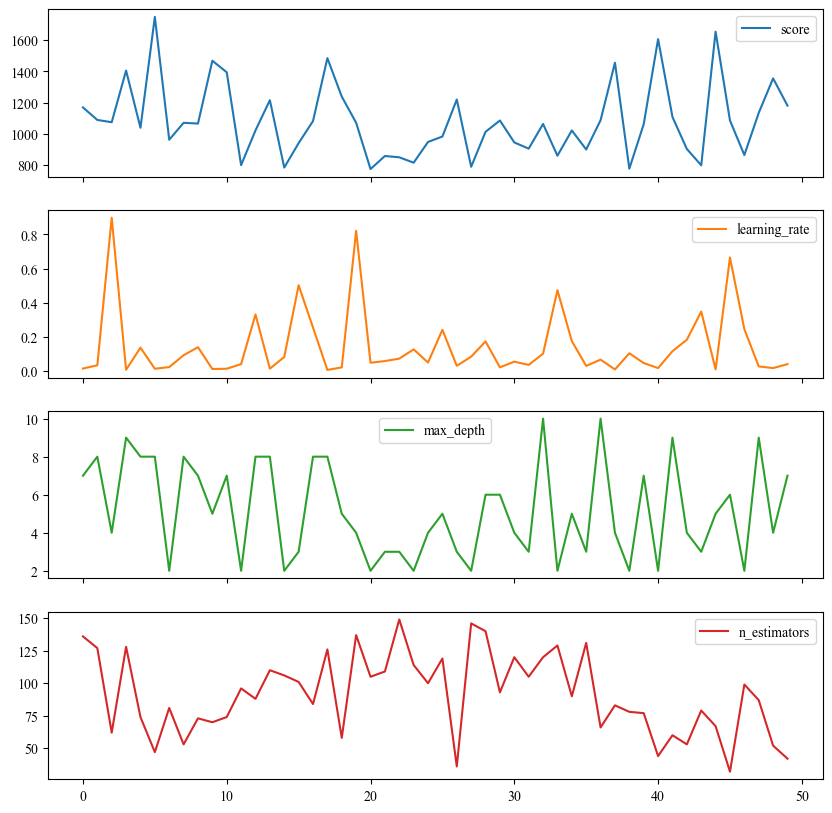

In [56]:
tpe_results = np.array(
    [
        [
            x["result"]["loss"],
            x["misc"]["vals"]["learning_rate"][0],
            x["misc"]["vals"]["max_depth"][0],
            x["misc"]["vals"]["n_estimators"][0],
        ]
        for x in trials.trials
    ]
)

tpe_results_df = pd.DataFrame(
    tpe_results, columns=["score", "learning_rate", "max_depth", "n_estimators"]
)
tpe_results_df.plot(subplots=True, figsize=(10, 10))
'''
rs_results_df=pd.DataFrame(np.transpose([-rs.cv_results_['mean_test_score'],
                                         rs.cv_results_['param_learning_rate'].data,
                                         rs.cv_results_['param_max_depth'].data,
                                         rs.cv_results_['param_n_estimators'].data]),
                           columns=['score', 'learning_rate', 'max_depth', 'n_estimators'])
rs_results_df.plot(subplots=True, figsize=(10, 10))
'''

In [57]:
tpe_results_df.to_csv('tpe_results.csv',index=False)

# Simulated Anneal模拟退火算法

In [58]:
# possible values of parameters
'''
space={'n_estimators': hp.quniform('n_estimators', 1, 150, 1),
       'max_depth' : hp.quniform('max_depth', 2, 10, 1),
       'learning_rate': hp.loguniform('learning_rate', -5, 0)
      }'''
space={'n_estimators': hp.quniform('n_estimators', 30, 150, 1),
       'max_depth' : hp.quniform('max_depth', 2, 10, 1),
       'learning_rate': hp.loguniform('learning_rate', -5, 0),
       #'subsample': hp.quniform('subsample', 0.1, 1.0, 10),
       #'min_child_weight': hp.quniform('min_child_weight',1,7,4),
       #'colsample_bytree': hp.quniform('colsample_bytree',0.1, 1.0, 10), # subsample ratio of columns by tree
       #'max_delta_step': hp.quniform('max_delta_step',0.1, 1.0, 10),
       #'max_features':hp.choice('max_features',['auto','sqrt','log2',None]), 
      # 'gamma':hp.uniform('gamma',1,9),            
       #'reg_alpha': hp.quniform('reg_alpha',40, 100,1), # L1 regularization
       #'reg_lambda': hp.uniform('reg_lambda',0,1)# L2 regularization
      }

In [59]:
#Best MSE 3547.530 params {'colsample_bytree': 0.0, 'gamma': 8.946919502838902, 'learning_rate': 0.06992132555536061, 'max_delta_step': 0.0, 
#'max_depth': 9.0, 'min_child_weight': 0.0, 'n_estimators': 100.0, 'reg_alpha': 50.0, 'reg_lambda': 0.6536912918472014, 'subsample': 0.0}
# trials will contain logging information
trials = Trials()
#时间占用 s
start=timeit.default_timer()
#内存占用 mb
info_start = psutil.Process(os.getpid()).memory_info().rss/1024/1024
best=fmin(fn=gb_mse_cv, # function to optimize
          space=space, 
          algo=anneal.suggest, # optimization algorithm, hyperotp will select its parameters automatically
          max_evals=50, # maximum number of iterations
          trials=trials, # logging
          rstate=np.random.default_rng(random_state) # fixing random state for the reproducibility
         )
print('best:')
print(best)
# computing the score on the test set
model = XGBRegressor(#random_state=3, n_estimators=96,max_depth=2,learning_rate=0.0832,
                    n_estimators=int(best['n_estimators']),max_depth=int(best['max_depth']),learning_rate=best['learning_rate'],
                  #subsample=best['subsample'],#colsample_bytree=best['colsample_bytree'], max_delta_step=best['max_delta_step'], 
                   #min_child_weight=best['min_child_weight'],#, max_features=best['max_features'],
                   #gamma=best['gamma'],  reg_alpha=best['reg_alpha'], reg_lambda=best['reg_lambda']
)
model.fit(train_data,train_targets)
sa_test_score=mean_squared_error(test_targets, model.predict(test_data))
end=timeit.default_timer()
info_end = psutil.Process(os.getpid()).memory_info().rss/1024/1024

print('此程序运行占内存'+str(info_end-info_start)+'mB')
print('Running time:%.5fs'%(end-start))
print("Best MSE {:.3f} params {}".format( gb_mse_cv(best), best))


1169.2024619336983                                                                                                     
{'n_estimators': 136, 'max_depth': 7, 'learning_rate': 0.015495281324132052}                                           
869.8949757284347                                                                                                      
{'n_estimators': 98, 'max_depth': 4, 'learning_rate': 0.5668537374965246}                                              
982.309857241287                                                                                                       
{'n_estimators': 121, 'max_depth': 5, 'learning_rate': 0.07989639580198235}                                            
1023.6500991408135                                                                                                     
{'n_estimators': 140, 'max_depth': 5, 'learning_rate': 0.1529866470670521}                                             
987.3683175362846                       

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

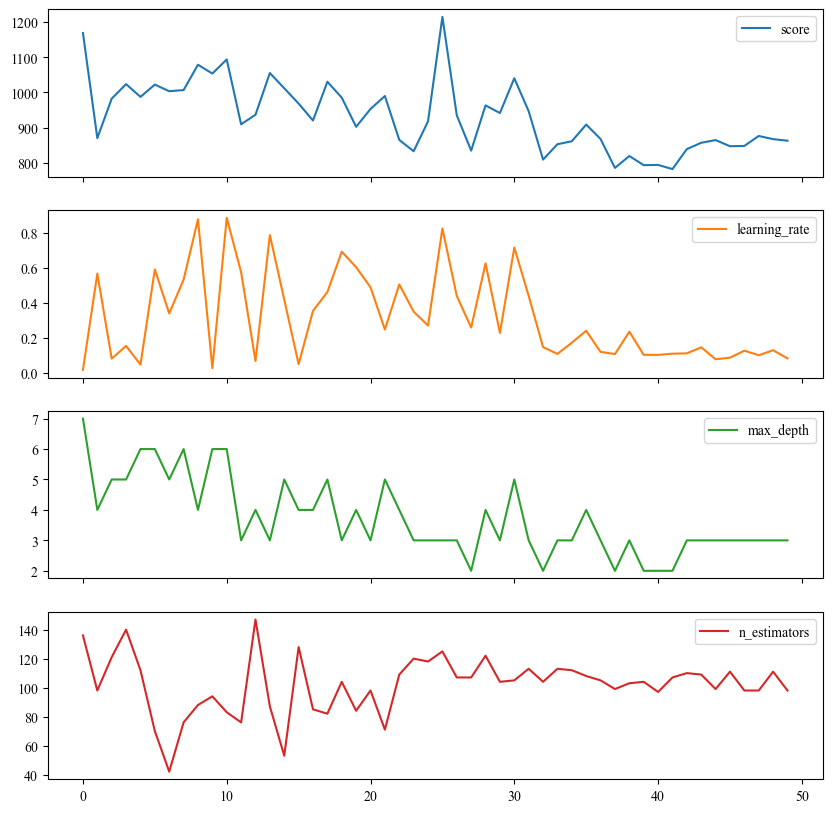

In [60]:
sa_results = np.array(
    [
        [
            x["result"]["loss"],
            x["misc"]["vals"]["learning_rate"][0],
            x["misc"]["vals"]["max_depth"][0],
            x["misc"]["vals"]["n_estimators"][0],
        ]
        for x in trials.trials
    ]
)

sa_results_df = pd.DataFrame(
    sa_results, columns=["score", "learning_rate", "max_depth", "n_estimators"]
)
sa_results_df.plot(subplots=True, figsize=(10, 10))

In [62]:
sa_results_df.to_csv('sa_results.csv',index=False)

In [61]:
# -------------------
# Predicting ...
# -------------------
y_pred = model.predict(test_data)
np.set_printoptions(precision=2)
test_results_as_df=pd.DataFrame({
    'Actual': test_targets,
    'Predicted_as': y_pred
})
test_results_as_df.to_csv('test_predictions_as.csv',index=False)

In [ ]:
# Results

Text(0, 0.5, 'best_cumulative_score')

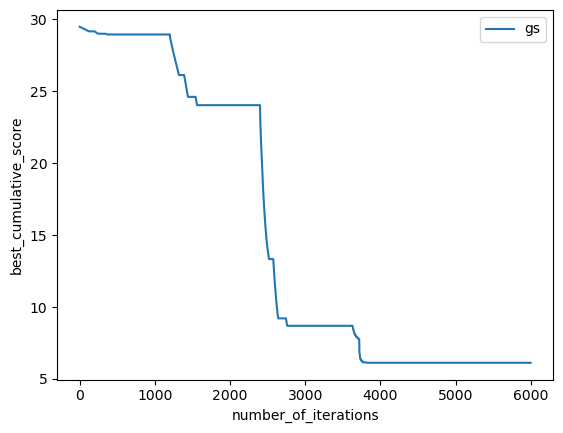

In [71]:
scores_df = pd.DataFrame(index=range(n_iter*120))
scores_df["gs"] = gs_results_df["score"].cummin()
ax = scores_df.plot()

ax.set_xlabel("number_of_iterations")
ax.set_ylabel("best_cumulative_score")

Text(0, 0.5, 'best_cumulative_score')

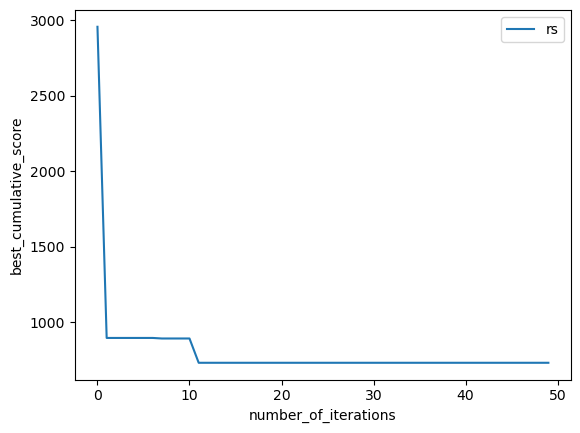

In [72]:
scores_df = pd.DataFrame(index=range(n_iter))
scores_df["rs"] = rs_results_df["score"].cummin()
ax = scores_df.plot()

ax.set_xlabel("number_of_iterations")
ax.set_ylabel("best_cumulative_score")

Text(0, 0.5, 'best_cumulative_score')

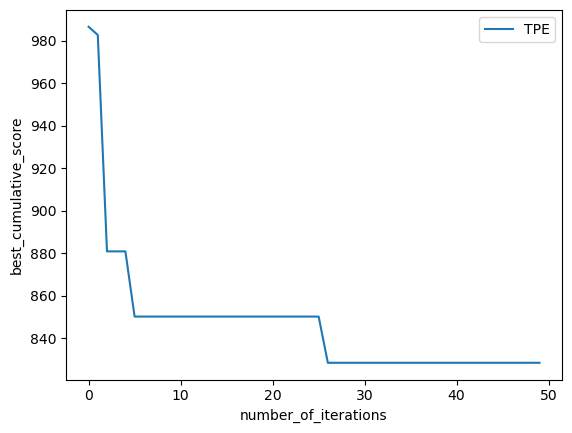

In [24]:
scores_df = pd.DataFrame(index=range(n_iter))
scores_df["TPE"] = tpe_results_df["score"].cummin()
ax = scores_df.plot()

ax.set_xlabel("number_of_iterations")
ax.set_ylabel("best_cumulative_score")

Text(0, 0.5, 'best_cumulative_score')

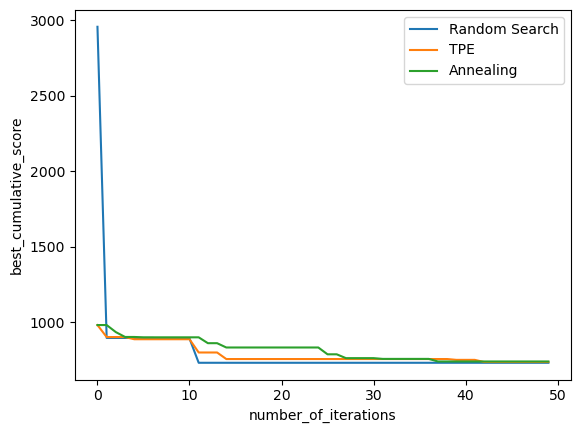

In [106]:
scores_df = pd.DataFrame(index=range(n_iter))
#scores_df["Grid Search"] = gs_results_df["score"].cummin()
scores_df["Random Search"] = rs_results_df["score"].cummin()
scores_df["TPE"] = tpe_results_df["score"].cummin()
scores_df["Annealing"] = sa_results_df["score"].cummin()

ax = scores_df.plot()

ax.set_xlabel("number_of_iterations")
ax.set_ylabel("best_cumulative_score")

In [105]:
scores_df

,rs
0,2956.533936
1,895.174180
2,895.174180
3,895.174180
4,895.174180
5,895.174180
6,895.174180
7,891.573714
8,891.573714
9,891.573714


In [77]:
scores_df_gs

,gs
0,29.483333
1,29.480693
2,29.478054
3,29.475416
4,29.472778
...,...
5995,6.123833
5996,6.123833
5997,6.123833
5998,6.123833


In [4]:
scores_df_gs = pd.read_csv('gs_results.csv',header=0)
scores_df = pd.read_csv('gs_tpe_sa_results_HPO.csv',header=0)

In [64]:
scores_df_gs

,GS,iterations,learning_rate,max_depth,n_estimators
0,3532.694513,1,0.0001,3,30
1,3532.201380,2,0.0001,3,31
2,3531.708294,3,0.0001,3,32
3,3531.215402,4,0.0001,3,33
4,3530.722557,5,0.0001,3,34
...,...,...,...,...,...
5995,1107.319608,5996,1.0000,10,145
5996,1107.319608,5997,1.0000,10,146
5997,1107.319608,5998,1.0000,10,147
5998,1107.319608,5999,1.0000,10,148


In [66]:
scores_df.head()

,iterations,RS,TPE,SA,learning_rate,max_depth,n_estimators
0,1,3555.036162,1748.585341,1215.056937,0.824951,3,125
1,2,3526.122190,1653.897070,1169.202462,0.015495,7,136
2,3,3110.936125,1606.216298,1093.953394,0.886509,6,83
3,4,1729.740241,1484.497162,1078.860008,0.877599,4,88
4,5,1157.838897,1467.805680,1055.277959,0.787268,3,87


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


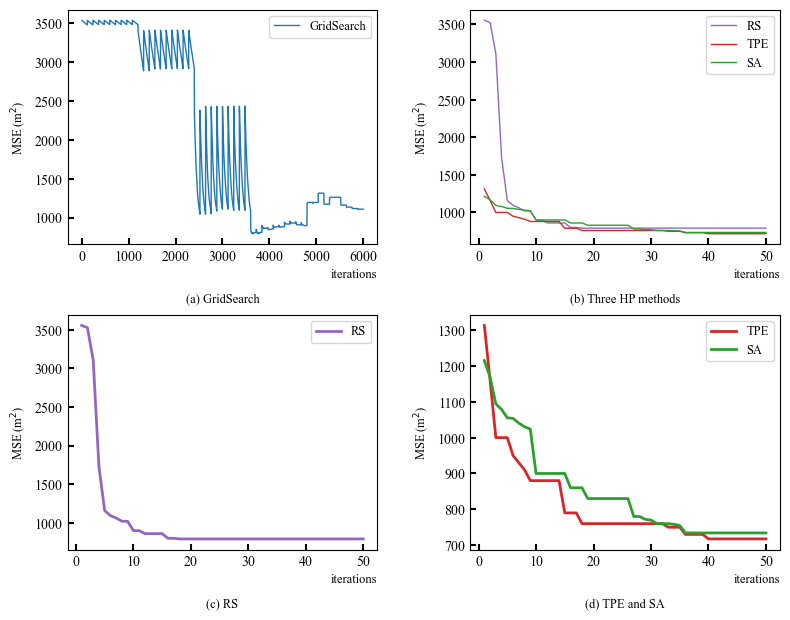

In [6]:
# 4. 创建一个图形窗口，包含多个子图
#from matplotlib.font_manager import FontProperties
#font_en = FontProperties(fname=r"c:\windows\Fonts\times.ttc", size=9)
fig, ax = plt.subplots(2,2, figsize=(8,6))  # 3行1列的子图   #plt.figure(figsize=(18/2.54, 5/2.54),dpi=400)
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['font.size'] = 7
# 网格优化
ax[0,0].plot(scores_df_gs['iterations'],scores_df_gs['GS'] , label='GridSearch', color='tab:blue', linewidth=1)#, marker='o', markersize=1)
# 设置标题和标签
ax[0,0].set_xlabel("iterations", fontsize=9, loc='right')#fontproperties=font_en,
ax[0,0].set_title('(a) GridSearch', y=-0.28,fontsize=9 )  #, weight='bold')
ax[0,0].set_ylabel(r'MSE (m$^2$)', fontsize=9 ) #, weight='bold')
ax[0,0].legend(['GridSearch'],fontsize=9,loc='best')
ax[0,0].tick_params(axis='both', which='both', direction='in', length=4, width=1.5)
#ax.grid(True, which='both', linestyle='--', linewidth=0.5)
#ax[0,0].set_xticks('iterations')#,loc=right)
# 随机优化
ax[0,1].plot(scores_df['iterations'],scores_df["RS"] , label='RS', color='tab:purple', linewidth=1)#, marker='o', markersize=1)
ax[0,1].plot(scores_df['iterations'],scores_df["TPE"], label='TPE', color='tab:red', linewidth=1)#, marker='o', markersize=1)
ax[0,1].plot(scores_df['iterations'],scores_df["SA"], label='SA', color='tab:green', linewidth=1)#, marker='o', markersize=1)
# 设置标题和标签
ax[0,1].set_xlabel("iterations", fontsize=9, loc='right')
ax[0,1].set_title('(b) Three HP methods',y=-0.28, fontsize=9) #, weight='bold')
ax[0,1].set_ylabel(r'MSE (m$^2$)', fontsize=9 ) #, weight='bold')
ax[0,1].legend(fontsize=9,loc='best')#['RS','TPE','SA'],
ax[0,1].tick_params(axis='both', which='both', direction='in', length=4, width=1.5)
#ax[0,1].text(3, 8, 'iterations')
# 随机优化
ax[1,0].plot(scores_df['iterations'],scores_df["RS"] , label='RS', color='tab:purple', linewidth=2)#, marker='o', markersize=1)
# 设置标题和标签
ax[1,0].set_xlabel("iterations", fontsize=9, loc='right')
ax[1,0].set_title('(c) RS',y=-0.28, fontsize=9) #, weight='bold')
ax[1,0].set_ylabel(r'MSE (m$^2$)', fontsize=9 ) #, )  weight='bold')
ax[1,0].legend(fontsize=9,loc='best')
ax[1,0].tick_params(axis='both', which='both', direction='in', length=4, width=1.5)
#ax[1,0].text(8, 5, 'iterations')
# 贝叶斯优化
ax[1,1].plot(scores_df['iterations'],scores_df["TPE"], label='TPE', color='tab:red', linewidth=2)#, marker='o', markersize=1)
ax[1,1].plot(scores_df['iterations'],scores_df["SA"], label='SA', color='tab:green', linewidth=2)#, marker='o', markersize=1)
# 设置标题和标签
ax[1,1].set_xlabel("iterations", fontsize=9, loc='right')
ax[1,1].set_title('(d) TPE and SA', y=-0.28,fontsize=9) #, weight='bold')
ax[1,1].set_ylabel(r'MSE (m$^2$)', fontsize=9) #, weight='bold')
ax[1,1].legend(fontsize=9,loc='best')
ax[1,1].tick_params(axis='both', which='both', direction='in', length=4, width=1.5)
#ax[1,1].text(8, 8, 'iterations')
# 设置图表的总体标题
#fig.suptitle('XGBoost Regressor: MSE vs Hyperparameters', fontsize=8, ) #, weight='bold')

# 调整布局，防止标签被遮挡
plt.tight_layout()
plt.subplots_adjust(wspace=0.4)  # 调整整体标题的位置
#plt.subplots_adjust(left=0.125,bottom=-0.51,right=1.3,top=0.88,hspace=1.2)
plt.subplots_adjust(top=1,bottom=0.1,hspace=0.3,wspace=0.3)
# 保存为适合出版的图片格式
plt.savefig('XGBoost_all_optimaztion_paras0421.tiff',bbox_inches='tight', dpi=300)
plt.savefig('XGBoost_all_optimaztion_paras0421.svg',bbox_inches='tight', dpi=300)
plt.savefig('XGBoost_all_optimaztion_paras0421.eps',bbox_inches='tight', dpi=300)
plt.savefig('XGBoost_all_optimaztion_paras0421.pdf',bbox_inches='tight', dpi=300)
plt.show()

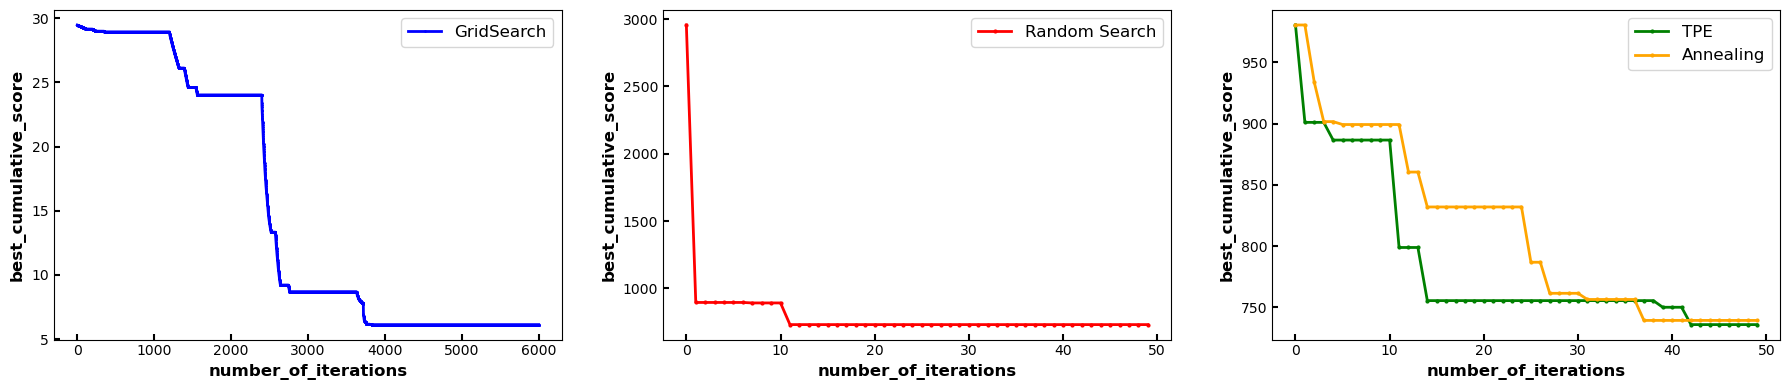

In [107]:
# 4. 创建一个图形窗口，包含多个子图
fig, ax = plt.subplots(1, 3, figsize=(18, 4))  # 3行1列的子图   #plt.figure(figsize=(18/2.54, 5/2.54),dpi=400)

# 网格优化
ax[0].plot(scores_df_gs.index,scores_df_gs['GS'] , label='GridSearch', color='blue', linewidth=2, marker='o', markersize=1)
# 设置标题和标签
ax[0].set_xlabel('number_of_iterations', fontsize=12, weight='bold')
ax[0].set_ylabel(r'best_cumulative_score', fontsize=12, weight='bold')
ax[0].legend(fontsize=12)
ax[0].tick_params(axis='both', which='both', direction='in', length=4, width=1.5)
#ax.grid(True, which='both', linestyle='--', linewidth=0.5)
# 随机优化
ax[1].plot(scores_df.index,scores_df["Random Search"] , label='Random Search', color='red', linewidth=2, marker='o', markersize=2)
# 设置标题和标签
# 设置标题和标签
ax[1].set_xlabel('number_of_iterations', fontsize=12, weight='bold')
ax[1].set_ylabel(r'best_cumulative_score', fontsize=12, weight='bold')
ax[1].legend(fontsize=12)
ax[1].tick_params(axis='both', which='both', direction='in', length=4, width=1.5)

# 贝叶斯优化
ax[2].plot(scores_df.index,scores_df["TPE"], label='TPE', color='green', linewidth=2, marker='o', markersize=2)
ax[2].plot(scores_df.index,scores_df["Annealing"], label='Annealing', color='orange', linewidth=2, marker='o', markersize=2)
# 设置标题和标签
# 设置标题和标签
ax[2].set_xlabel('number_of_iterations', fontsize=12, weight='bold')
ax[2].set_ylabel(r'best_cumulative_score', fontsize=12, weight='bold')
ax[2].legend(fontsize=12)
ax[2].tick_params(axis='both', which='both', direction='in', length=4, width=1.5)

# 设置图表的总体标题
#fig.suptitle('XGBoost Regressor: MSE vs Hyperparameters', fontsize=8, weight='bold')

# 调整布局，防止标签被遮挡
plt.tight_layout()
plt.subplots_adjust(wspace=0.2)  # 调整整体标题的位置
#plt.subplots_adjust(left=0.125,bottom=-0.51,right=1.3,top=0.88,hspace=1.2)

# 保存为适合出版的图片格式
plt.savefig('XGBoost_all_optimaztion_paras02170.png', dpi=400)
plt.show()

In [12]:
# 读取CSV文件
test_results_all = pd.read_csv('test_predictions_gs20250223OK.csv',header=0)  #,encoding='gbk'

In [22]:
test_results_all

,Actual,Predicted_gs,Predicted_rs,Predicted_tpe,Predicted_as
0,29.31,31.213440,31.871525,41.109740,34.326214
1,146.18,117.574990,111.075670,131.499490,110.468230
2,175.40,105.041985,121.883930,168.205680,119.626330
3,45.00,35.397960,33.824696,36.183136,35.562010
4,120.00,173.257370,170.785720,150.800340,171.640820
5,96.30,68.362720,72.868650,73.896120,77.292150
6,109.30,97.516610,95.828680,98.424890,95.977540
7,45.00,23.910631,29.315584,31.532797,34.777298
8,67.20,74.490450,77.375114,78.650375,78.380040
9,88.03,148.859440,140.342850,99.030530,133.771970
